In [1]:
import gensim
import gensim.downloader as api

print("Gensim version:", gensim.__version__)
print("Gensim is working!")

Gensim version: 4.4.0
Gensim is working!


In [3]:
import gensim.downloader as api

models = [
    "word2vec-google-news-300",
    "fasttext-wiki-news-subwords-300",
    "glove-wiki-gigaword-300"
]

for model_name in models:
    info = api.info(model_name)
    print(f"{model_name}")
    print(f"  Dimensions : {info['parameters']['dimension']}")
    print(f"  Estimated size : {info['file_size']}")
    print()

word2vec-google-news-300
  Dimensions : 300
  Estimated size : 1743563840

fasttext-wiki-news-subwords-300
  Dimensions : 300
  Estimated size : 1005007116

glove-wiki-gigaword-300
  Dimensions : 300
  Estimated size : 394362229



In [4]:
import gensim.downloader as api

print("Downloading Word2Vec...")
word2vec = api.load("word2vec-google-news-300")

print("Word2Vec loaded successfully!")
print("Vocabulary size:", len(word2vec.key_to_index))
print("Embedding dimension:", word2vec.vector_size)


Word2Vec loaded successfully!
Vocabulary size: 3000000
Embedding dimension: 300


In [5]:
result = word2vec.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

print("king - man + woman:")
for word, score in result:
    print(f"{word}: {score:.4f}")
    

king - man + woman:
queen: 0.7118
monarch: 0.6190
princess: 0.5902
crown_prince: 0.5499
prince: 0.5377


In [6]:
for word in ["happy", "computer"]:
    print(f"\nTop 5 similar words for '{word}':")
    
    results = word2vec.most_similar(word, topn=5)
    
    for w, score in results:
        print(f"{w}: {score:.4f}")


Top 5 similar words for 'happy':
glad: 0.7409
pleased: 0.6632
ecstatic: 0.6627
overjoyed: 0.6599
thrilled: 0.6514

Top 5 similar words for 'computer':
computers: 0.7979
laptop: 0.6640
laptop_computer: 0.6549
Computer: 0.6473
com_puter: 0.6082


In [7]:
test_word = "computerr"

try:
    vector = word2vec[test_word]
    print(f"'{test_word}' is available.")
    print("Vector dimension:", len(vector))
except KeyError:
    print(f"'{test_word}' is NOT in the Word2Vec vocabulary.")
    print("Result: OOV (Out-of-Vocabulary)")

'computerr' is NOT in the Word2Vec vocabulary.
Result: OOV (Out-of-Vocabulary)


In [8]:
import gensim.downloader as api

print("Downloading fastText...")
fasttext = api.load("fasttext-wiki-news-subwords-300")

print("fastText loaded successfully!")
print("Vocabulary size:", len(fasttext.key_to_index))
print("Embedding dimension:", fasttext.vector_size)

fastText loaded successfully!
Vocabulary size: 999999
Embedding dimension: 300


In [9]:
result = fasttext.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

print("king - man + woman:")
for word, score in result:
    print(f"{word}: {score:.4f}")

king - man + woman:
queen: 0.7787
queen-mother: 0.7144
king-: 0.6981
queen-consort: 0.6725
monarch: 0.6667


In [10]:
for word in ["happy", "computer"]:
    print(f"\nTop 5 similar words for '{word}':")
    
    results = fasttext.most_similar(word, topn=5)
    
    for w, score in results:
        print(f"{w}: {score:.4f}")
        


Top 5 similar words for 'happy':
happpy: 0.8086
happy-: 0.7918
happy-happy: 0.7885
unhappy: 0.7820
happier: 0.7645

Top 5 similar words for 'computer':
computers: 0.8473
non-computer: 0.8157
mini-computer: 0.8100
micro-computer: 0.7728
super-computer: 0.7625


In [11]:
test_word = "computerr"

try:
    vector = fasttext[test_word]
    print(f"'{test_word}' is available in fastText.")
    print("Vector dimension:", len(vector))
    print("Result: fastText can generate an embedding.")
except KeyError:
    print(f"'{test_word}' is NOT available.")

'computerr' is NOT available.


In [12]:
test_word = "computerr"

print("In vocabulary:", test_word in fasttext.key_to_index)

try:
    vector = fasttext.get_vector(test_word)
    print("Vector generated successfully!")
    print("Vector dimension:", len(vector))
except Exception as e:
    print("Could not generate vector.")
    print("Error:", type(e).__name__, e)

In vocabulary: False
Could not generate vector.
Error: KeyError "Key 'computerr' not present"


In [13]:
import gensim.downloader as api

print("Downloading GloVe...")
glove = api.load("glove-wiki-gigaword-300")

print("GloVe loaded successfully!")
print("Vocabulary size:", len(glove.key_to_index))
print("Embedding dimension:", glove.vector_size)

[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe loaded successfully!
Vocabulary size: 400000
Embedding dimension: 300


In [14]:
result = glove.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

print("king - man + woman:")
for word, score in result:
    print(f"{word}: {score:.4f}")

king - man + woman:
queen: 0.6713
princess: 0.5433
throne: 0.5386
monarch: 0.5348
daughter: 0.4980


In [15]:
for word in ["happy", "computer"]:
    print(f"\nTop 5 similar words for '{word}':")
    
    results = glove.most_similar(word, topn=5)
    
    for w, score in results:
        print(f"{w}: {score:.4f}")



Top 5 similar words for 'happy':
'm: 0.7080
glad: 0.6905
pleased: 0.6712
really: 0.6576
always: 0.6495

Top 5 similar words for 'computer':
computers: 0.8248
software: 0.7334
pc: 0.6240
technology: 0.6199
computing: 0.6179


In [16]:
test_word = "computerr"

try:
    vector = glove[test_word]
    print(f"'{test_word}' is available in GloVe.")
    print("Vector dimension:", len(vector))
except KeyError:
    print(f"'{test_word}' is NOT in the GloVe vocabulary.")
    print("Result: OOV (Out-of-Vocabulary)")

'computerr' is NOT in the GloVe vocabulary.
Result: OOV (Out-of-Vocabulary)


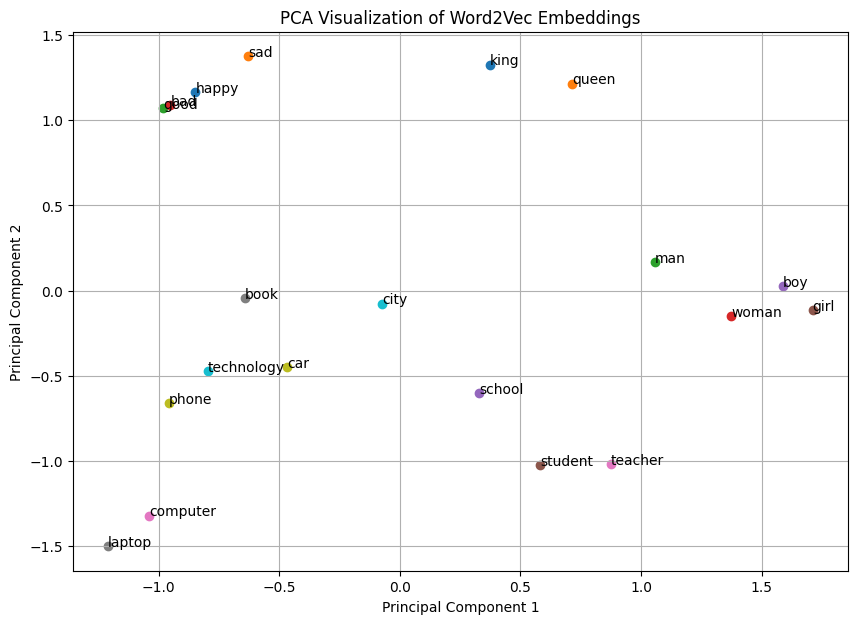

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = [
    "king", "queen", "man", "woman",
    "boy", "girl", "computer", "laptop",
    "phone", "technology", "happy", "sad",
    "good", "bad", "school", "student",
    "teacher", "book", "car", "city"
]

# Use Word2Vec for the common visualization
vectors = [word2vec[word] for word in words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))

for i, word in enumerate(words):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

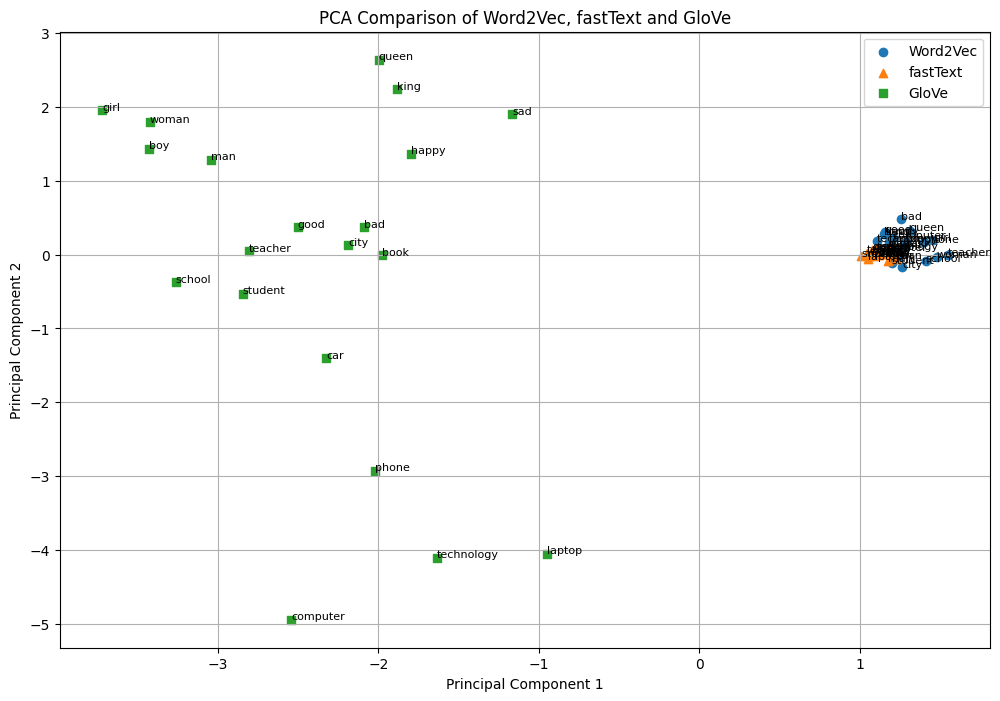

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

words = [
    "king", "queen", "man", "woman",
    "boy", "girl", "computer", "laptop",
    "phone", "technology", "happy", "sad",
    "good", "bad", "school", "student",
    "teacher", "book", "car", "city"
]

models = {
    "Word2Vec": word2vec,
    "fastText": fasttext,
    "GloVe": glove
}

# Collect embeddings from all three models
all_vectors = []
labels = []
model_names = []

for model_name, model in models.items():
    for word in words:
        if word in model.key_to_index:
            all_vectors.append(model[word])
            labels.append(word)
            model_names.append(model_name)

# Convert to NumPy array
all_vectors = np.array(all_vectors)

# Reduce 300 dimensions to 2
pca = PCA(n_components=2)
reduced = pca.fit_transform(all_vectors)

# Plot
plt.figure(figsize=(12, 8))

markers = {
    "Word2Vec": "o",
    "fastText": "^",
    "GloVe": "s"
}

for model_name in models:
    indices = [
        i for i, name in enumerate(model_names)
        if name == model_name
    ]

    plt.scatter(
        reduced[indices, 0],
        reduced[indices, 1],
        marker=markers[model_name],
        label=model_name
    )

    for i in indices:
        plt.annotate(
            labels[i],
            (reduced[i, 0], reduced[i, 1]),
            fontsize=8
        )

plt.title("PCA Comparison of Word2Vec, fastText and GloVe")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

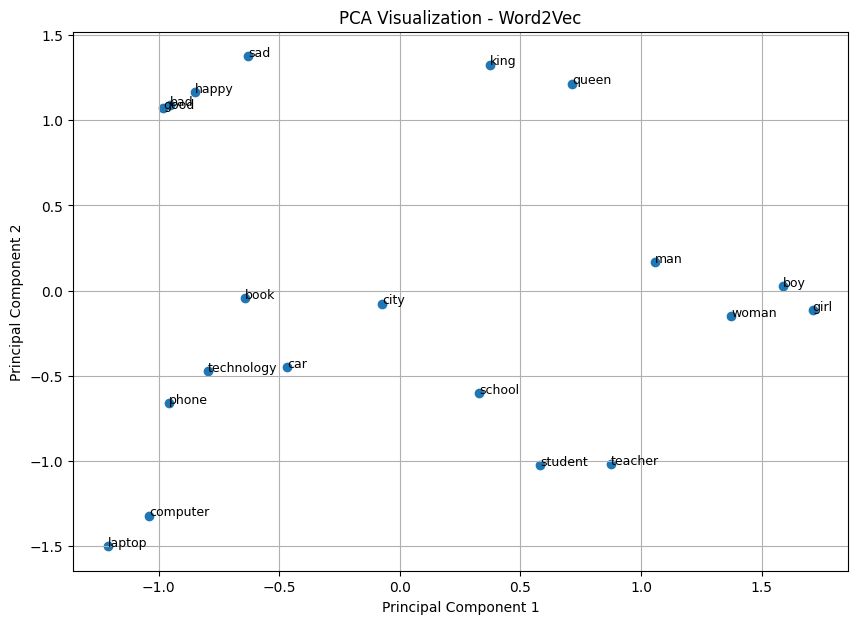

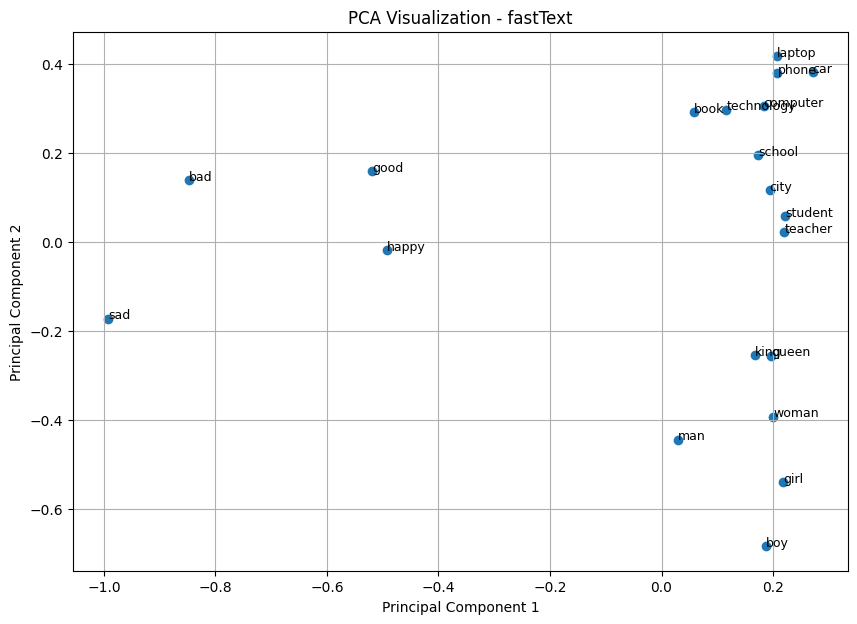

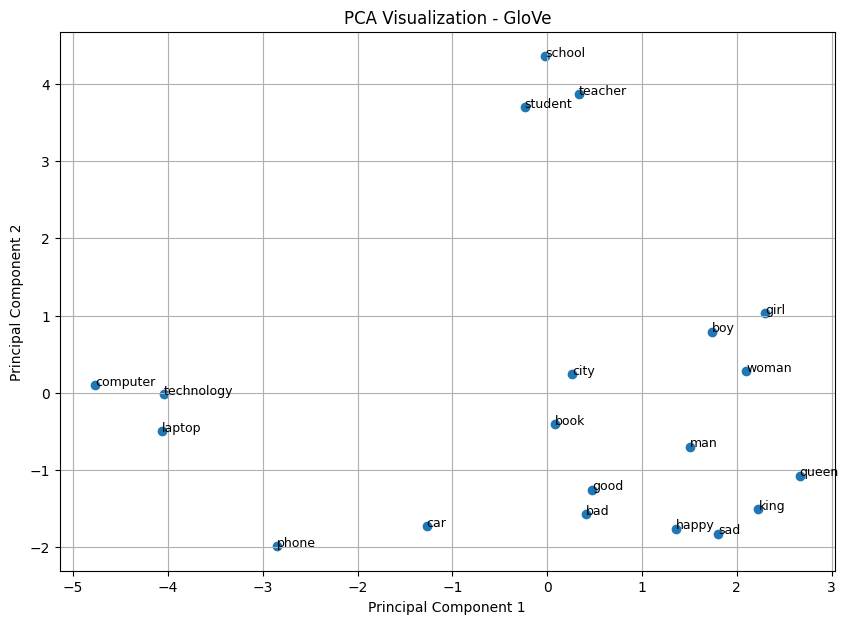

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = [
    "king", "queen", "man", "woman",
    "boy", "girl", "computer", "laptop",
    "phone", "technology", "happy", "sad",
    "good", "bad", "school", "student",
    "teacher", "book", "car", "city"
]

models = {
    "Word2Vec": word2vec,
    "fastText": fasttext,
    "GloVe": glove
}

for model_name, model in models.items():

    # Get vectors for the same 20 words
    vectors = [model[word] for word in words]

    # Reduce 300 dimensions → 2 dimensions
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 7))

    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, word in enumerate(words):
        plt.annotate(
            word,
            (reduced[i, 0], reduced[i, 1]),
            fontsize=9
        )

    plt.title(f"PCA Visualization - {model_name}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.show()

In [20]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Word2Vec", "fastText", "GloVe"],
    "Vocabulary Size": [3000000, 999999, 400000],
    "Embedding Dimension": [300, 300, 300],
    "Analogy Top Result": ["queen", "queen", "queen"],
    "Analogy Similarity": [0.7118, 0.7787, 0.6713],
    "OOV: computerr": ["Not available", "Not available", "Not available"]
})

comparison

,Model,Vocabulary Size,Embedding Dimension,Analogy Top Result,Analogy Similarity,OOV: computerr
0,Word2Vec,3000000,300,queen,0.7118,Not available
1,fastText,999999,300,queen,0.7787,Not available
2,GloVe,400000,300,queen,0.6713,Not available
